# Temperature and humidity parameters

This notebook demonstrates how temperature and humidity influence the acoustical simulation.

The first experiment varies temperature and humidity for the same didgeridoo bore and computes the fundamental note.

Text(50.722222222222214, 0.5, 'Temperature [°C]')

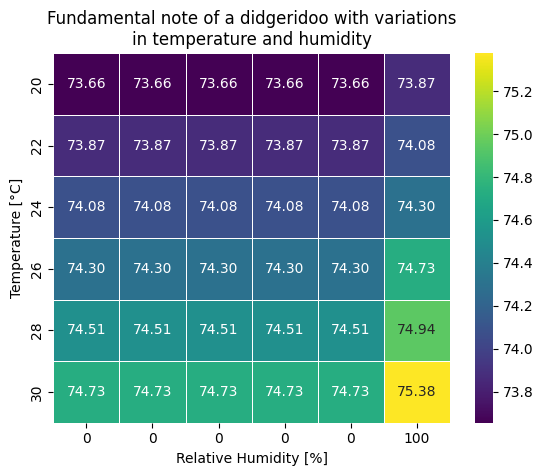

In [4]:
import numpy as np
import sys
sys.path.append("..")
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from didgelab import acoustical_simulation, Geo, plot_bore, get_log_simulation_frequencies, \
    compute_moist_air_properties
from scipy.signal import argrelmax

geo = [[0.0, 30.0], [51.46899363230762, 33.7784524142553], [85.30423566381049, 27.778931402719003], [146.18854416328128, 29.93556480319699], [179.09381040534882, 28.176128566813905], [259.6802069488814, 28.958055614249236], [285.8190435948692, 32.523925651740726], [371.25522284885295, 28.657844125210218], [419.84135591763703, 29.58434155089998], [466.51643935886017, 29.918981345641743], [527.3904014120826, 31.90101706990902], [531.1184504606866, 34.99886886158793], [602.3168197366772, 32.507540421468754], [662.7828119015719, 36.93351761826125], [696.8927839128953, 35.045862969399295], [746.6898985029628, 36.84736191316634], [815.4460816003736, 39.05244109202236], [832.2110323436855, 43.81877757673142], [848.9759830869973, 48.23024903217608], [865.7409338303091, 51.74295627153961], [882.505884573621, 54.20771815807003], [899.2708353169328, 55.56194698443228], [916.0357860602446, 55.32924009903286], [932.8007368035564, 53.87356959783409], [949.5656875468683, 57.597070298366724], [966.3306382901801, 60.18361651506194], [999.0345487680597, 64.33061402881069], [1015.6645962439811, 65.73163097400256], [1032.2946437199025, 65.17490857100057], [1048.924691195824, 62.75626540369139], [1065.5547386717453, 58.79571998981954], [1082.1847861476667, 54.17039891202623], [1119.7483374925102, 50.13599574849312], [1145.100343149991, 52.07082961850034], [1196.9667987935184, 52.785312404146595], [1275.3325429113545, 51.631734726631564], [1310.4749184562197, 49.258375148257805], [1360.5050929455278, 55.86662095119183], [1432.9324204516163, 57.034846444202294], [1447.2181347373307, 57.6709182777631], [1461.503849023045, 58.180684544167576], [1475.7895633087592, 58.54248286994988], [1490.0752775944734, 58.97267620477503], [1504.3609918801878, 59.524557312640155], [1518.646706165902, 60.26754363477322], [1532.9324204516163, 62.288373855176175], [1547.2181347373307, 64.72655249320907], [1561.503849023045, 67.72346991377412], [1575.7895633087592, 70.39265102058911], [1590.0752775944734, 73.44970066456183], [1604.3609918801878, 77.47427770386149], [1618.646706165902, 82.64877489218449]]
geo = Geo(geo)


frequencies = get_log_simulation_frequencies()

temperatures = np.linspace(20, 30, 6).round(decimals=1)
humidities = np.linspace(0, 1.0, 6).astype(int)

results = []
for temp in temperatures:
    row = []
    for humidity in humidities:
        constants = compute_moist_air_properties(temp_celsius=temp, rel_humidity=humidity)
        impedance = acoustical_simulation(geo, frequencies, constants=constants, simulation_method = "tlm_cython")
        fundamental = frequencies[argrelmax(impedance)][0]
        row.append(fundamental)
    results.append(row)        

results = pd.DataFrame(results)

sns.heatmap(
    results,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    xticklabels=humidities * 100,
    yticklabels=temperatures.astype(int),
)

plt.title("Fundamental note of a didgeridoo with variations\nin temperature and humidity")
plt.xlabel("Relative Humidity [%]")
plt.ylabel("Temperature [°C]")


This experiment shows the impedance spectrum of two didgeridoos, one at 20°C and 0% humidity, the other one at 28°C and 100% humidity.

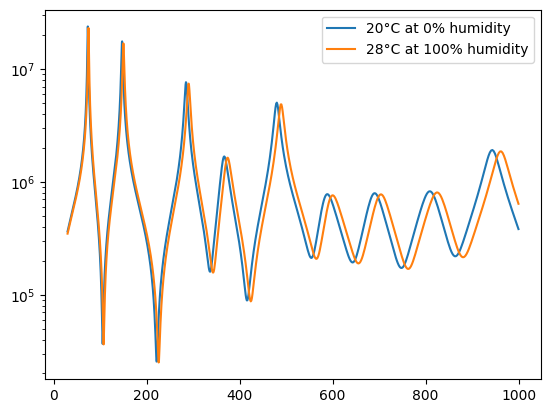

In [8]:
import numpy as np

constants = compute_moist_air_properties(temp_celsius=20, rel_humidity=0)
impedance = acoustical_simulation(geo, frequencies, constants=constants, simulation_method = "tlm_cython")
plt.plot(frequencies, impedance, label='20°C at 0% humidity')

constants = compute_moist_air_properties(temp_celsius=28, rel_humidity=1)
impedance = acoustical_simulation(geo, frequencies, constants=constants, simulation_method = "tlm_cython")
plt.plot(frequencies, impedance, label='28°C at 100% humidity')
plt.yscale("log")

plt.legend()

In [6]:
# verify that temperature and humidity change all simulation methods

methods = ["tlm_python", "tlm_cython", "1d_fem", "2d_fem"]
temperatures = [20, 30]
humidities = [0, 1]
results = []
for method in methods:
    row = {
        "method": method
    }
    for label, temperature, humidity in [("cold_dry", 20, 0), ("warm_moist", 30,1)]:
        constants = compute_moist_air_properties(temp_celsius=temp, rel_humidity=humidity)
        impedance = acoustical_simulation(geo, frequencies, constants=constants, simulation_method = method)
        fundamental = frequencies[argrelmax(impedance)][0]
        row[f'fundamental_{label}'] = fundamental
    results.append(row)

results = pd.DataFrame(results)
results.round(2)

,method,fundamental_cold_dry,fundamental_warm_moist
0,tlm_python,74.73,75.38
1,tlm_cython,74.73,75.38
2,1d_fem,74.94,75.60
3,2d_fem,74.94,75.38
